# Flow Matching — Jacobian geometry comparison
Our UNet (grayscale 64×64) vs HF pre-trained (RGB 64×64).

In [2]:
import os, sys, math
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
from huggingface_hub import hf_hub_download
from flow_matching.models import UNetModel
from datasets import load_dataset
import torchvision.transforms as T

sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))
from model import UNetFM

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

/home/onyxia/work/MLresearch_solo/compare_notebook/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cuda


## Config

In [3]:
OURS_CKPT      = 'unet_fm_celeba_gray64.pt'
GDRIVE_FILE_ID = "1KH1SjXoCmS71cBVYwEagmuuXKYz3lLbF"
HF_MODEL_ID = 'WayBob/FlowMatching-Unet-Celeb-64x64'
T_VALUES    = [0.15, 0.35, 0.50, 0.70, 0.85, 0.95]
K_LANCZOS   = 300
K_SHOW      = 12
N_ODE_STEPS = 100
SEED        = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

## Load models

In [4]:
# ── Acquire our checkpoint ────────────────────────────────────────────────────
# Priority: 1) already present  2) Google Drive  3) train from scratch

_ckpt = Path(__file__).parent / OURS_CKPT if '__file__' in dir() else Path(OURS_CKPT)

if not _ckpt.exists():
    if GDRIVE_FILE_ID:
        import gdown
        print(f"Downloading {OURS_CKPT} from Google Drive...")
        gdown.download(id=GDRIVE_FILE_ID, output=str(_ckpt), quiet=False)
    else:
        print(f"{OURS_CKPT} not found — training from scratch (~30 epochs)...")
        import time
        import torchvision.transforms as _T

        _transform = _T.Compose([
            _T.Grayscale(),
            _T.Resize(64, interpolation=_T.InterpolationMode.BICUBIC),
            _T.CenterCrop(64),
            _T.ToTensor(),
            _T.Normalize([0.5], [0.5]),
        ])
        _EPOCHS, _BS, _N = 30, 256, 160_000
        print(f"Loading CelebA ({_N} images)...")
        _ds      = load_dataset('tglcourse/CelebA-faces-cropped-128', split='train')
        _X       = torch.stack([_transform(_ds[i]['image']) for i in tqdm(range(_N), desc='preprocess')]).to(device)
        _m       = UNetFM(1, 64, (1,2,4,8), 256).to(device)
        _opt     = torch.optim.AdamW(_m.parameters(), lr=1e-4, weight_decay=1e-4)
        _sched   = torch.optim.lr_scheduler.CosineAnnealingLR(_opt, T_max=_EPOCHS)
        _scaler  = torch.amp.GradScaler('cuda')
        _mc      = torch.compile(_m); _mc.train()
        for ep in range(_EPOCHS):
            t0 = time.time(); loss_sum = 0; nb_b = 0
            for s in range(0, _N, _BS):
                idx = torch.randperm(_N, device=device)[s:s+_BS]
                x1 = _X[idx]; x0 = torch.randn_like(x1)
                t  = torch.rand(x1.shape[0], device=device)
                xt = t[:,None,None,None]*x1 + (1-t[:,None,None,None])*x0
                with torch.amp.autocast('cuda'):
                    loss = torch.nn.functional.mse_loss(_mc(t, xt), x1 - x0)
                _opt.zero_grad(set_to_none=True); _scaler.scale(loss).backward()
                _scaler.unscale_(_opt); torch.nn.utils.clip_grad_norm_(_m.parameters(), 1.0)
                _scaler.step(_opt); _scaler.update()
                loss_sum += loss.item(); nb_b += 1
            _sched.step()
            print(f"epoch {ep+1:3d}/{_EPOCHS}  loss={loss_sum/nb_b:.4f}  {time.time()-t0:.0f}s")
        torch.save(_m.state_dict(), str(_ckpt))
        print(f"Saved to {_ckpt}")

OURS_CKPT = str(_ckpt)
print(f"checkpoint: {OURS_CKPT}")

checkpoint: unet_fm_celeba_gray64.pt


In [5]:
model_ours = UNetFM(img_ch=1, base_ch=64, ch_mults=(1,2,4,8), time_dim=256).to(device)
model_ours.load_state_dict(torch.load(OURS_CKPT, map_location=device))
model_ours.eval()

IMG_OURS, CH_OURS = 64, 1
DIM_OURS = IMG_OURS * IMG_OURS * CH_OURS
print(f"ours   : {sum(p.numel() for p in model_ours.parameters())/1e6:.1f}M params")

ours   : 13.3M params


In [6]:
ckpt_path = hf_hub_download(repo_id=HF_MODEL_ID, filename='celeba64/ckpt.pth')
model_hf = UNetModel(
    dim=(3, 64, 64), num_channels=128,
    num_res_blocks=2, num_classes=0, class_cond=False,
).to(device)
model_hf.load_state_dict(torch.load(ckpt_path, map_location=device, weights_only=True))
model_hf.eval()

IMG_HF, CH_HF = 64, 3
DIM_HF = IMG_HF * IMG_HF * CH_HF
print(f"HF     : {sum(p.numel() for p in model_hf.parameters())/1e6:.1f}M params")

HF     : 83.0M params


## Generate samples

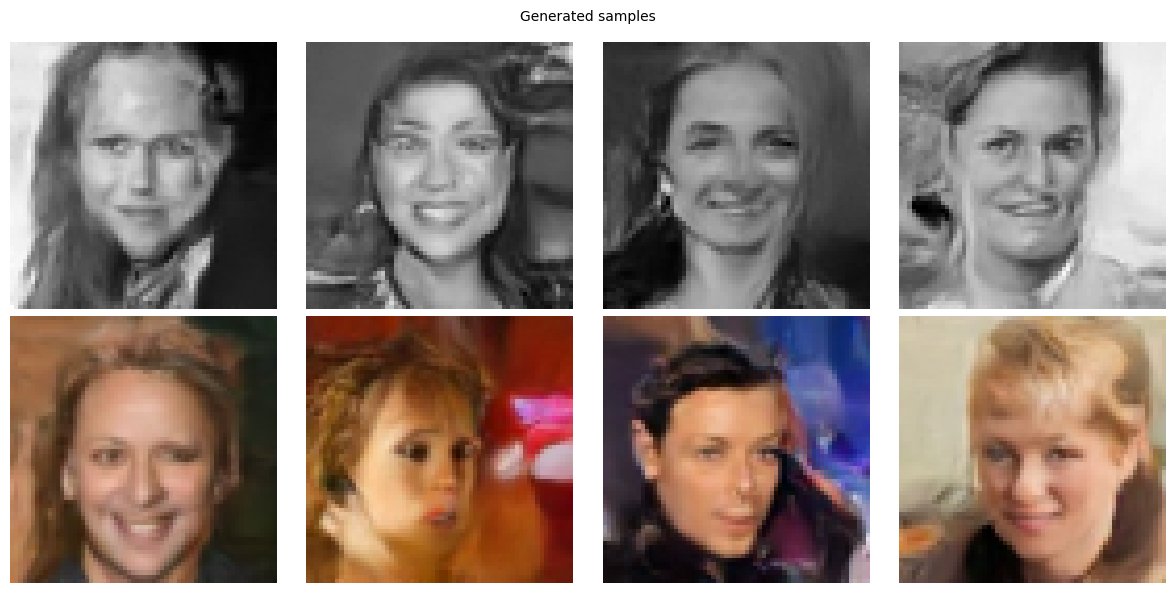

In [7]:
def sample_ode(model, shape, n_steps=100, seed=42):
    torch.manual_seed(seed)
    x = torch.randn(*shape, device=device)
    dt = 1.0 / n_steps
    with torch.no_grad():
        for i in tqdm(range(n_steps), desc='ODE', leave=False):
            t_b = torch.full((shape[0],), i / n_steps, device=device)
            x = x + model(t_b, x) * dt
    return x

def to_gray(t):
    return (t.squeeze().cpu().float().numpy() * 0.5 + 0.5).clip(0, 1)

def to_rgb(t):
    img = t.squeeze(0).permute(1,2,0).cpu().float().numpy()
    return ((img + 1) * 127.5).clip(0, 255).astype(np.uint8)

x1_ours = sample_ode(model_ours, (4, CH_OURS, IMG_OURS, IMG_OURS), N_ODE_STEPS, SEED)
x1_hf   = sample_ode(model_hf,   (4, CH_HF,   IMG_HF,   IMG_HF),   N_ODE_STEPS, SEED)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(4):
    axes[0, i].imshow(to_gray(x1_ours[i:i+1]), cmap='gray', vmin=0, vmax=1); axes[0, i].axis('off')
    axes[1, i].imshow(Image.fromarray(to_rgb(x1_hf[i:i+1]))); axes[1, i].axis('off')
axes[0, 0].set_ylabel('ours (gray)', fontsize=9, rotation=0, labelpad=65, va='center')
axes[1, 0].set_ylabel('HF (RGB)',    fontsize=9, rotation=0, labelpad=65, va='center')
plt.suptitle('Generated samples', fontsize=10)
plt.tight_layout(); plt.show()

## Lanczos eigsh

In [8]:
def eigvec_lum(E, k, ch, sz):
    ek = E[:, k].float().view(ch, sz, sz)
    return ek.mean(0).numpy() if ch > 1 else ek.squeeze().numpy()

def make_vjp_fn(model, xt_ref, t_val, ch, sz):
    def vjp_fn(v):
        x = xt_ref.clone().float().requires_grad_(True)
        with torch.enable_grad():
            t_b = torch.full((1,), t_val, device=x.device)
            D = x + (1.0 - t_val) * model(t_b, x)
            (D * v.view(1, ch, sz, sz)).sum().backward()
        return x.grad.flatten().detach()
    return vjp_fn

def lanczos_eigsh(Av_fn, d, n_iter, device, dtype=torch.float32):
    q = torch.randn(d, device=device, dtype=dtype); q /= q.norm()
    Q      = torch.zeros(d, n_iter, device=device, dtype=dtype)
    alphas = torch.zeros(n_iter,     device=device, dtype=dtype)
    betas  = torch.zeros(n_iter - 1, device=device, dtype=dtype)
    Q[:, 0] = q
    r = Av_fn(q); alphas[0] = (q * r).sum(); r -= alphas[0] * q
    last = 0
    for j in tqdm(range(1, n_iter), desc='Lanczos', leave=False):
        beta = r.norm().item()
        if beta < 1e-10: break
        betas[j-1] = beta; Q[:, j] = r / beta
        r = Av_fn(Q[:, j])
        alphas[j] = (Q[:, j] * r).sum()
        r -= alphas[j] * Q[:, j] + beta * Q[:, j-1]
        r -= Q[:, :j+1] @ (Q[:, :j+1].T @ r)
        last = j
    m = last + 1
    T = torch.diag(alphas[:m].cpu()) + torch.diag(betas[:m-1].cpu(), 1) + torch.diag(betas[:m-1].cpu(), -1)
    evals, evecs_T = torch.linalg.eigh(T)
    evecs = Q[:, :m] @ evecs_T.to(device)
    idx = evals.argsort(descending=True)
    return evals[idx].cpu(), evecs[:, idx].cpu()

def run_sweep(model, x1_ref, eps, ch, sz, dim, t_values):
    res = {}
    for t_val in t_values:
        xt = t_val * x1_ref + (1.0 - t_val) * eps
        with torch.no_grad():
            t_b  = torch.full((1,), t_val, device=device)
            pred = xt + (1.0 - t_val) * model(t_b, xt)
        psnr = 10 * math.log10(4.0 / (F.mse_loss(pred, x1_ref).item() + 1e-12))
        vjp      = make_vjp_fn(model, xt, t_val, ch, sz)
        lam, E   = lanczos_eigsh(vjp, dim, K_LANCZOS, device)
        coeffs   = (x1_ref.flatten().float().cpu() @ E).abs()
        res[t_val] = {'lam': lam.numpy(), 'E': E, 'coeffs': coeffs.numpy(),
                      'xt': xt.detach(), 'pred': pred.detach(), 'psnr': psnr}
        print(f't={t_val}  λ₁={lam[0]:.3f}  PSNR={psnr:.1f} dB')
    return res

## Sweep t — both models

In [9]:
x1_ours_ref = x1_ours[0:1].to(device)
x1_hf_ref   = x1_hf[0:1].to(device)
torch.manual_seed(0)
eps_ours = torch.randn_like(x1_ours_ref)
eps_hf   = torch.randn_like(x1_hf_ref)

print('── our model ──')
results_ours = run_sweep(model_ours, x1_ours_ref, eps_ours, CH_OURS, IMG_OURS, DIM_OURS, T_VALUES)
print('\n── HF model ──')
results_hf   = run_sweep(model_hf,   x1_hf_ref,   eps_hf,   CH_HF,   IMG_HF,   DIM_HF,   T_VALUES)

── our model ──


t=0.15  λ₁=6.498  PSNR=14.5 dB


t=0.35  λ₁=3.694  PSNR=19.9 dB


t=0.5  λ₁=2.509  PSNR=22.4 dB


t=0.7  λ₁=1.858  PSNR=25.7 dB


...

t=0.35  λ₁=3.897  PSNR=23.4 dB


t=0.5  λ₁=2.776  PSNR=25.7 dB


t=0.7  λ₁=1.856  PSNR=29.1 dB


t=0.85  λ₁=1.612  PSNR=33.2 dB


t=0.95  λ₁=1.394  PSNR=39.4 dB


## Figures
### Eigenvalue spectra

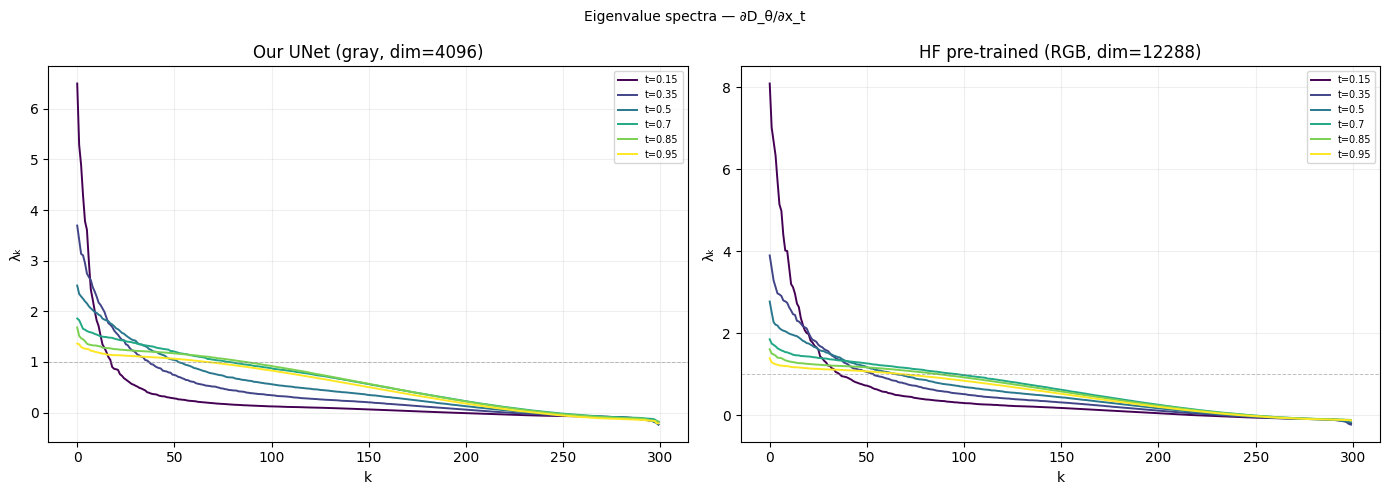

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.cm.viridis(np.linspace(0, 1, len(T_VALUES)))

for ax, results, title in [
    (axes[0], results_ours, f'Our UNet (gray, dim={DIM_OURS})'),
    (axes[1], results_hf,   f'HF pre-trained (RGB, dim={DIM_HF})'),
]:
    for i, t in enumerate(T_VALUES):
        ax.plot(results[t]['lam'], color=colors[i], lw=1.4, label=f't={t}')
    ax.axhline(1.0, ls='--', color='gray', lw=0.7, alpha=0.5)
    ax.set(xlabel='k', ylabel='λₖ', title=title); ax.legend(fontsize=7); ax.grid(alpha=0.2)

plt.suptitle('Eigenvalue spectra — ∂D_θ/∂x_t', fontsize=10)
plt.tight_layout(); plt.show()

### λₖ vs t

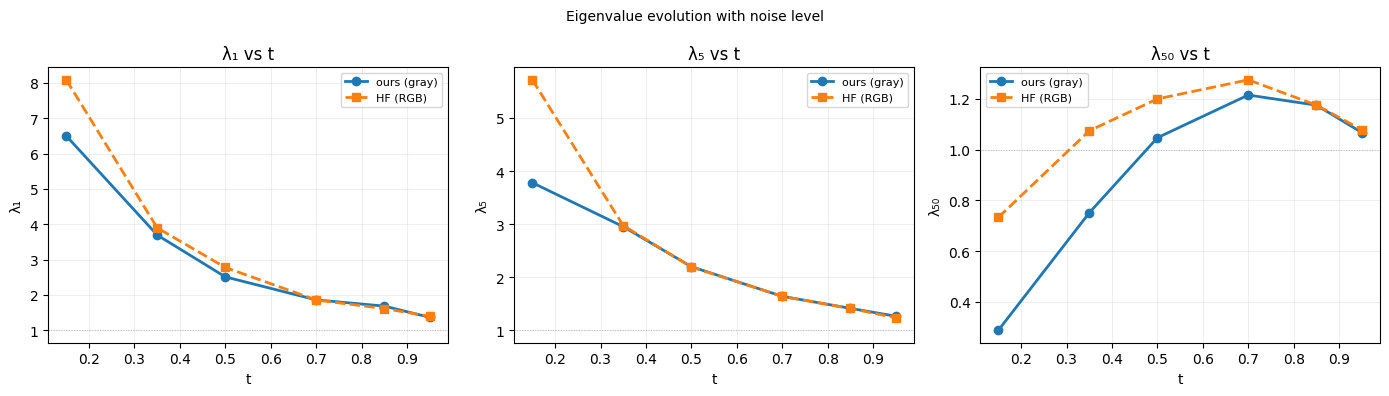

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, k, label in zip(axes, [0, 4, 49], ['λ₁', 'λ₅', 'λ₅₀']):
    t_ok_o = [t for t in T_VALUES if k < len(results_ours[t]['lam'])]
    t_ok_h = [t for t in T_VALUES if k < len(results_hf[t]['lam'])]
    ax.plot(t_ok_o, [results_ours[t]['lam'][k] for t in t_ok_o], 'o-',  lw=2, label='ours (gray)')
    ax.plot(t_ok_h, [results_hf[t]['lam'][k]   for t in t_ok_h], 's--', lw=2, label='HF (RGB)')
    ax.axhline(1.0, ls=':', color='gray', lw=0.7, alpha=0.5)
    ax.set(xlabel='t', ylabel=label, title=f'{label} vs t'); ax.legend(fontsize=8); ax.grid(alpha=0.2)

plt.suptitle('Eigenvalue evolution with noise level', fontsize=10)
plt.tight_layout(); plt.show()

### Decay alignment (λₖ vs ⟨x₁, eₖ⟩)

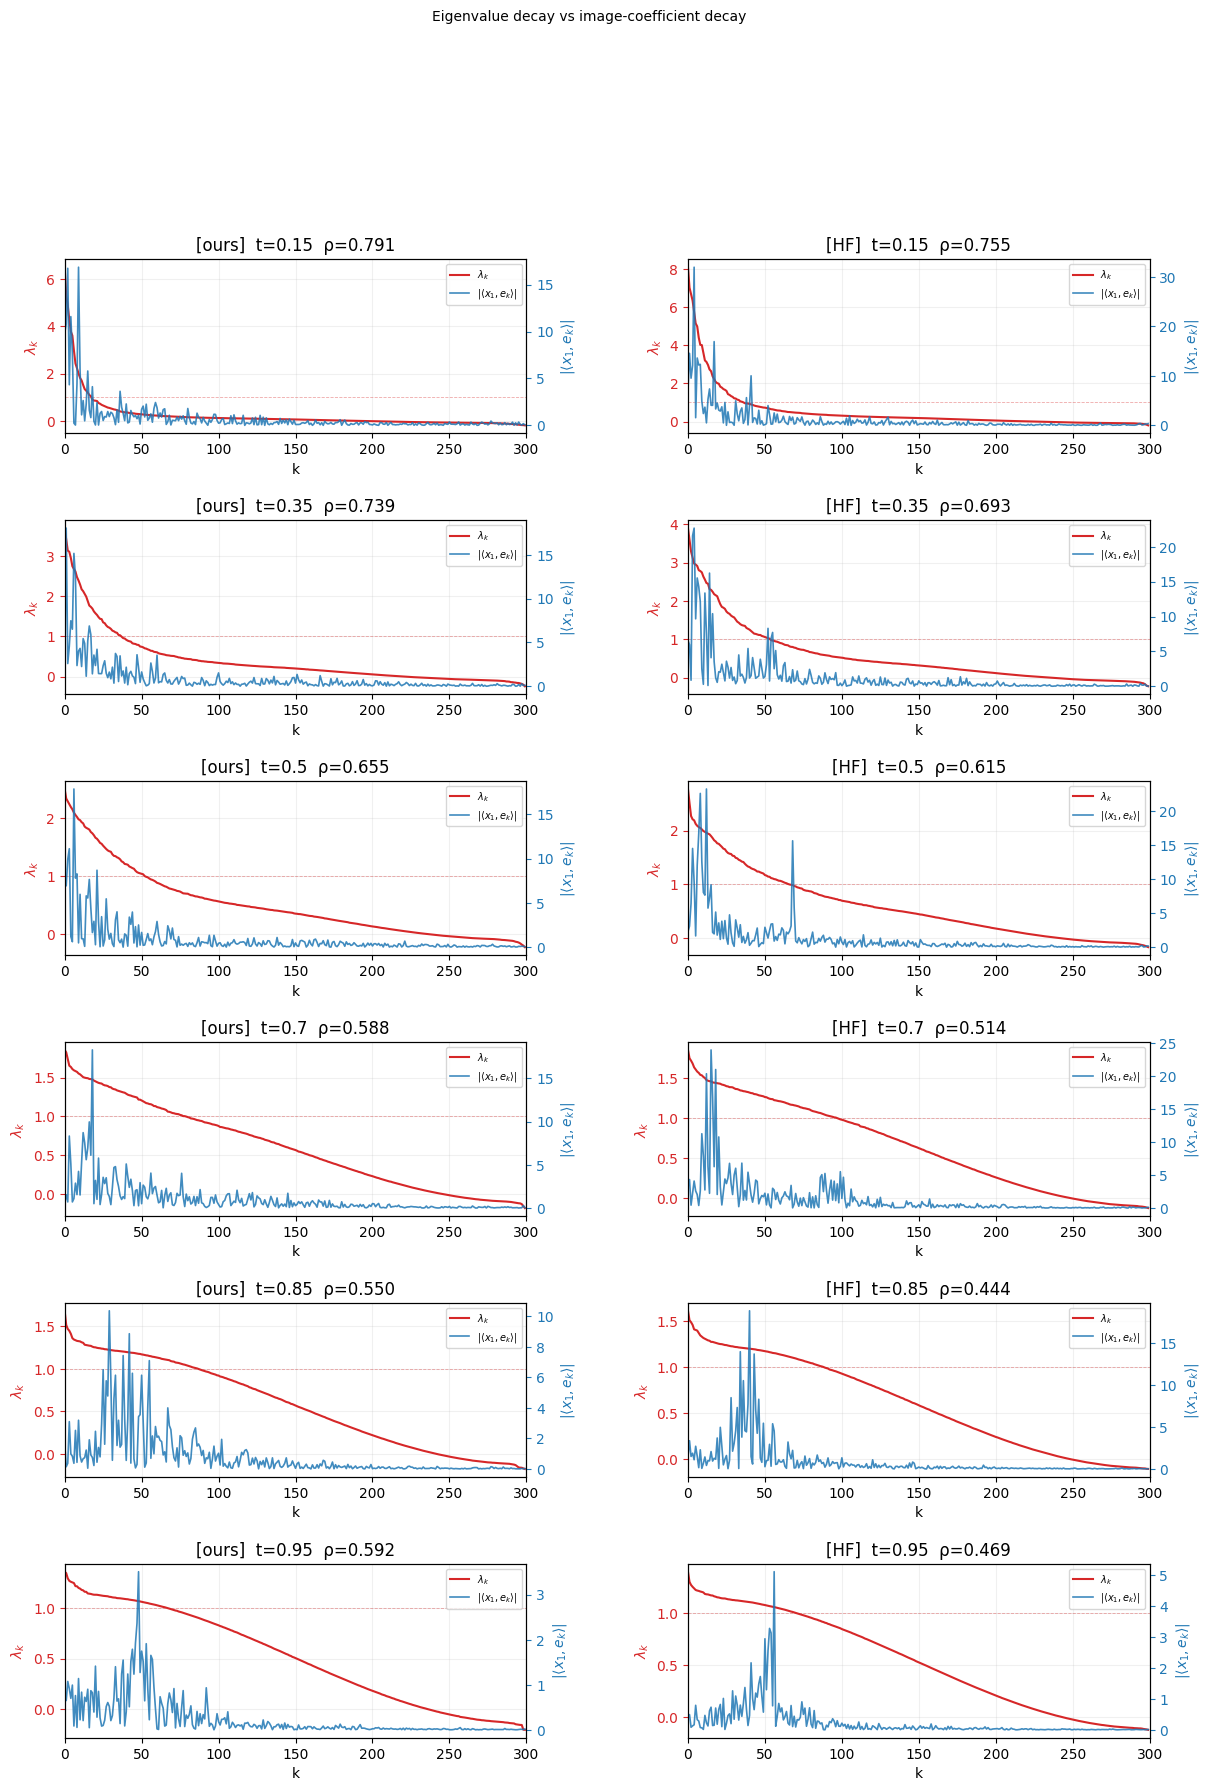

In [12]:
fig, axes = plt.subplots(len(T_VALUES), 2, figsize=(14, 3.2*len(T_VALUES)),
                         gridspec_kw={'hspace': 0.50, 'wspace': 0.35})

for row, t_val in enumerate(T_VALUES):
    for col, (results, tag) in enumerate([(results_ours, 'ours'), (results_hf, 'HF')]):
        res  = results[t_val]
        lam, coef = res['lam'], res['coeffs']
        k    = np.arange(len(lam))
        rho  = np.corrcoef(lam[:len(coef)], coef[:len(lam)])[0, 1]
        ax   = axes[row, col]; ax2 = ax.twinx()
        ax.plot(k, lam,  color='#d62728', lw=1.5, label=r'$\lambda_k$')
        ax.axhline(1.0, ls='--', color='#d62728', lw=0.6, alpha=0.4)
        ax2.plot(k, coef, color='#1f77b4', lw=1.2, alpha=0.85, label=r'$|\langle x_1,e_k\rangle|$')
        ax.set(xlabel='k', xlim=(0, len(lam)),
               title=f'[{tag}]  t={t_val}  ρ={rho:.3f}')
        ax.set_ylabel(r'$\lambda_k$', color='#d62728')
        ax2.set_ylabel(r'$|\langle x_1,e_k\rangle|$', color='#1f77b4')
        ax.tick_params(axis='y', colors='#d62728'); ax2.tick_params(axis='y', colors='#1f77b4')
        ax.grid(alpha=0.18)
        lines  = ax.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
        labels = ax.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
        ax.legend(lines, labels, fontsize=7, loc='upper right')

plt.suptitle('Eigenvalue decay vs image-coefficient decay', fontsize=10, y=1.01)
plt.show()

### Eigenvector grids

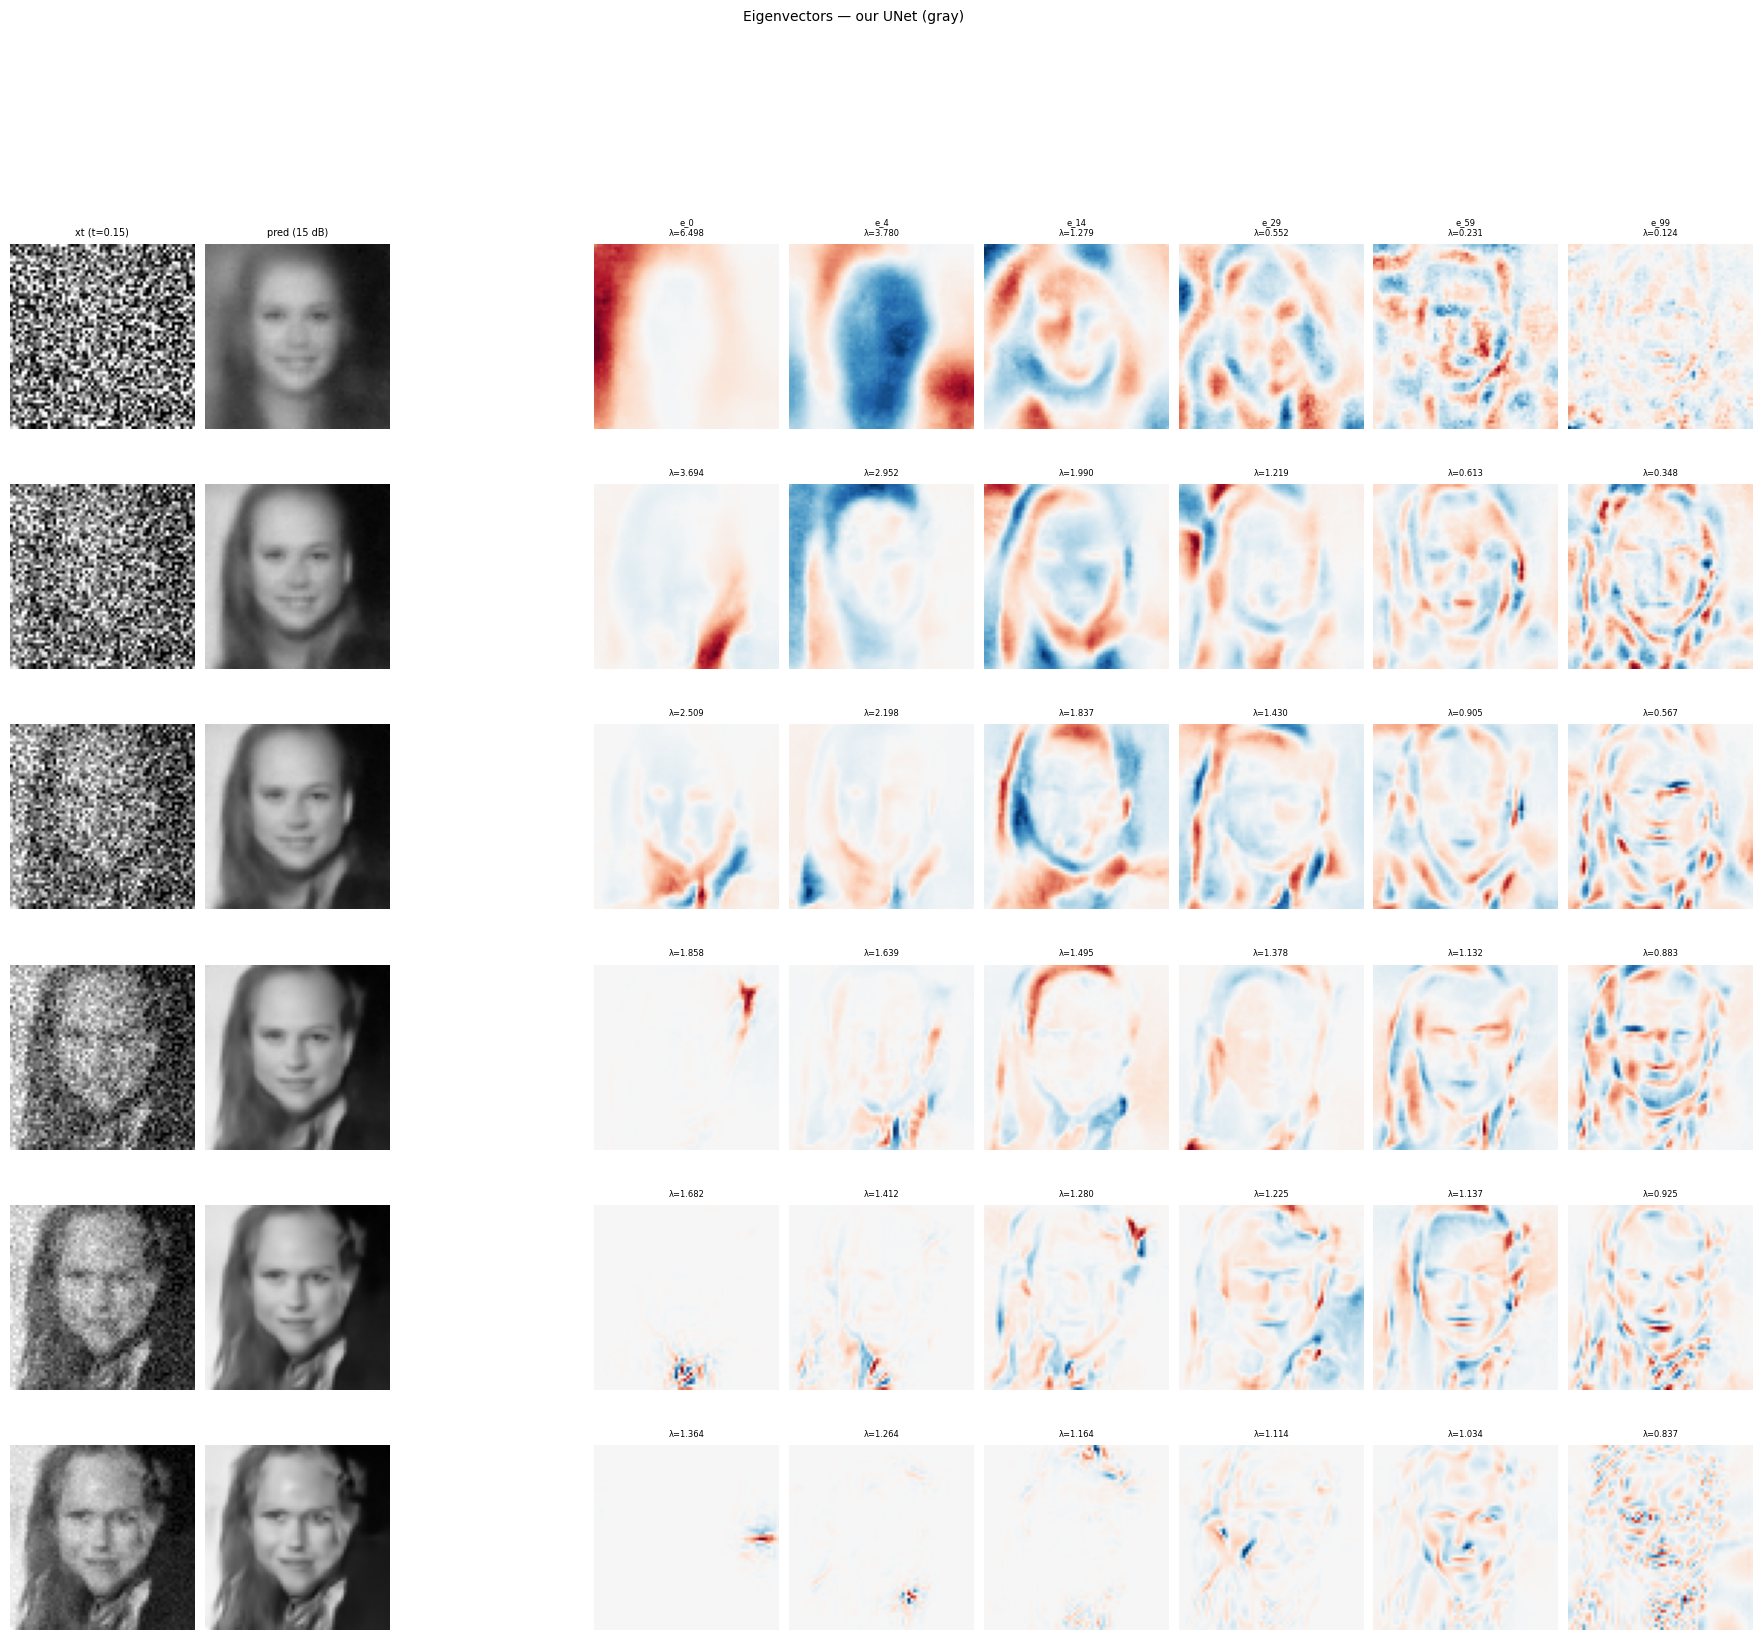

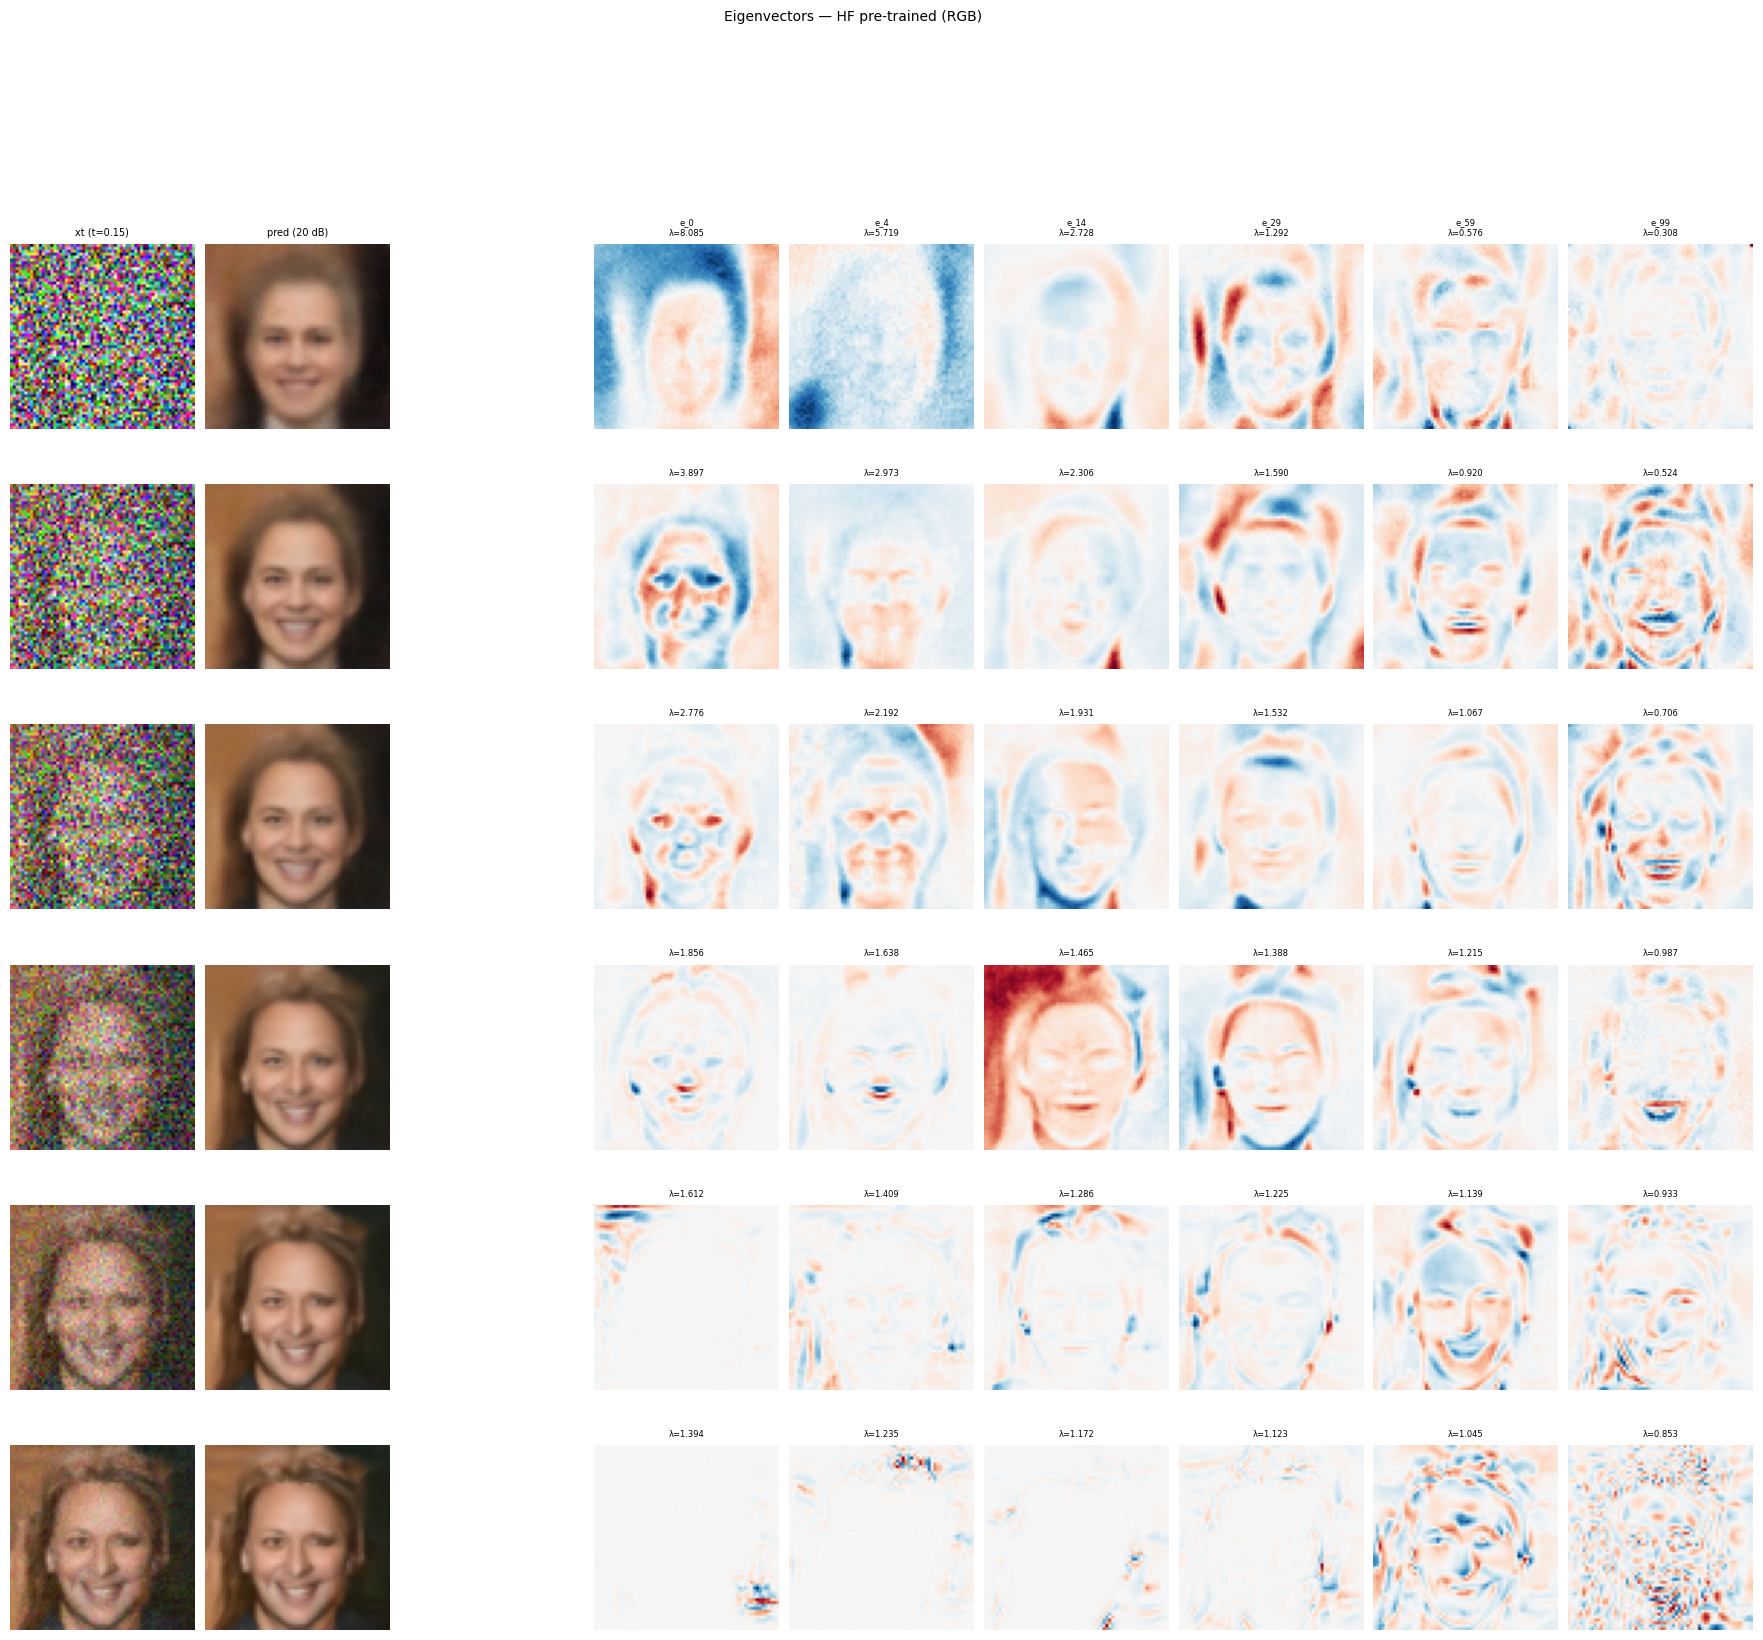

In [13]:
def show_img(ax, t, ch):
    if ch == 1: ax.imshow(to_gray(t), cmap='gray', vmin=0, vmax=1)
    else:       ax.imshow(Image.fromarray(to_rgb(t)))

def show_eigvec_grid(results, ch, sz, title):
    k_display = [k for k in [0, 4, 14, 29, 59, 99] if k < K_LANCZOS]
    n_cols = 3 + len(k_display)
    fig, axes = plt.subplots(len(T_VALUES), n_cols, figsize=(2.5*n_cols, 3*len(T_VALUES)),
                              gridspec_kw={'wspace': 0.05, 'hspace': 0.3})
    for row, t_val in enumerate(T_VALUES):
        res = results[t_val]
        for col, (img, ttl) in enumerate([(res['xt'].cpu()[0:1], f'xt (t={t_val})'),
                                           (res['pred'].cpu()[0:1], f'pred ({res["psnr"]:.0f} dB)')]):
            show_img(axes[row, col], img, ch)
            if row == 0: axes[row, col].set_title(ttl, fontsize=7)
            axes[row, col].axis('off')
        axes[row, 2].axis('off')
        for i_ev, k in enumerate(k_display):
            ax = axes[row, 3 + i_ev]
            lum = eigvec_lum(res['E'], k, ch, sz)
            vmax = np.abs(lum).max() + 1e-8
            ax.imshow(lum, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
            lbl = f'e_{k}\nλ={res["lam"][k]:.3f}' if row == 0 else f'λ={res["lam"][k]:.3f}'
            ax.set_title(lbl, fontsize=6); ax.axis('off')
    fig.suptitle(title, fontsize=10, y=1.01); plt.show()

show_eigvec_grid(results_ours, CH_OURS, IMG_OURS, 'Eigenvectors — our UNet (gray)')
show_eigvec_grid(results_hf,   CH_HF,   IMG_HF,   'Eigenvectors — HF pre-trained (RGB)')

## Real CelebA image

fetching CelebA #160042...


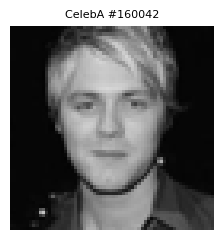

t=0.35  λ₁=3.284  PSNR=21.0 dB


In [14]:
CELEBA_IDX = 160_042
T_FIG      = [0.35]
T_SPEC     = 0.35
K_EIG_SHOW = 9

_transform = T.Compose([
    T.Grayscale(),
    T.Resize(IMG_OURS, interpolation=T.InterpolationMode.BICUBIC),
    T.CenterCrop(IMG_OURS),
    T.ToTensor(),
    T.Normalize([0.5], [0.5]),
])

print(f'fetching CelebA #{CELEBA_IDX}...')
_ds      = load_dataset('tglcourse/CelebA-faces-cropped-128', split='train', streaming=True)
_sample  = next(iter(_ds.skip(CELEBA_IDX).take(1)))
x1_final = _transform(_sample['image']).unsqueeze(0).to(device)

fig, ax = plt.subplots(figsize=(2.5, 2.5))
ax.imshow(to_gray(x1_final), cmap='gray', vmin=0, vmax=1); ax.axis('off')
ax.set_title(f'CelebA #{CELEBA_IDX}', fontsize=8)
plt.tight_layout(); plt.show()

torch.manual_seed(0)
eps_final     = torch.randn_like(x1_final)
results_final = run_sweep(model_ours, x1_final, eps_final,
                           CH_OURS, IMG_OURS, DIM_OURS,
                           sorted(set(T_FIG) | {T_SPEC}))

/tmp/ipykernel_4704/127232945.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


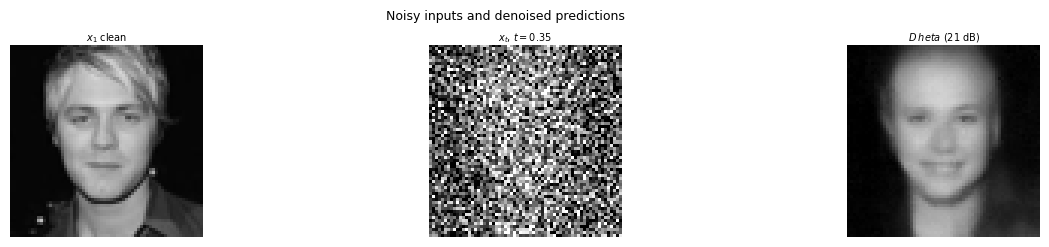

In [15]:
# images: clean / noisy / denoised
N_IMG_COLS = 1 + 2 * len(T_FIG)
fig, axes_A = plt.subplots(1, N_IMG_COLS, figsize=(max(16, 2.0*N_IMG_COLS), 2.5),
                            gridspec_kw={'wspace': 0.04})

axes_A[0].imshow(to_gray(x1_final), cmap='gray', vmin=0, vmax=1); axes_A[0].axis('off')
axes_A[0].set_title('$x_1$ clean', fontsize=7, pad=2)
for c_idx, t_val in enumerate(T_FIG):
    res = results_final[t_val]
    axes_A[1 + 2*c_idx].imshow(to_gray(res['xt']), cmap='gray', vmin=0, vmax=1)
    axes_A[1 + 2*c_idx].set_title(f'$x_t$, $t={t_val}$', fontsize=7, pad=2)
    axes_A[1 + 2*c_idx].axis('off')
    axes_A[2 + 2*c_idx].imshow(to_gray(res['pred']), cmap='gray', vmin=0, vmax=1)
    axes_A[2 + 2*c_idx].set_title(f'$D_\theta$ ({res["psnr"]:.0f} dB)', fontsize=7, pad=2)
    axes_A[2 + 2*c_idx].axis('off')

plt.suptitle('Noisy inputs and denoised predictions', fontsize=9, y=1.02)
plt.tight_layout(); plt.show()

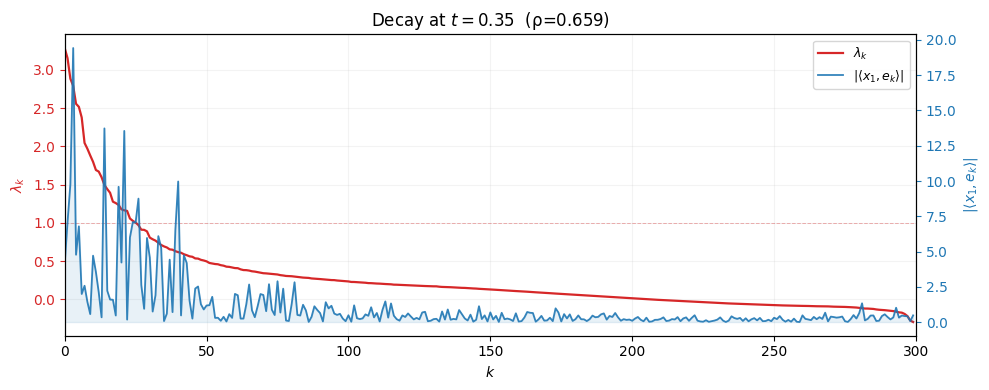

In [16]:
# spectrum at T_SPEC
res  = results_final[T_SPEC]
lam, coef = res['lam'], res['coeffs']
k    = np.arange(len(lam))
rho  = np.corrcoef(lam[:len(coef)], coef[:len(lam)])[0, 1]

fig, ax = plt.subplots(figsize=(10, 4)); ax2 = ax.twinx()
ax.plot(k, lam,  color='#d62728', lw=1.6, label=r'$\lambda_k$')
ax.axhline(1.0,  ls='--', color='#d62728', lw=0.7, alpha=0.35)
ax2.fill_between(k, coef, alpha=0.10, color='#1f77b4')
ax2.plot(k, coef, color='#1f77b4', lw=1.3, alpha=0.9, label=r'$|\langle x_1,e_k\rangle|$')
ax.set(xlabel='$k$', xlim=(0, len(lam)),
       title=rf'Decay at $t={T_SPEC}$  (ρ={rho:.3f})')
ax.set_ylabel(r'$\lambda_k$', color='#d62728')
ax2.set_ylabel(r'$|\langle x_1,e_k\rangle|$', color='#1f77b4')
ax.tick_params(axis='y', colors='#d62728'); ax2.tick_params(axis='y', colors='#1f77b4')
ax.grid(alpha=0.15)
lines  = ax.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
labels = ax.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax.legend(lines, labels, fontsize=9, loc='upper right')
plt.tight_layout(); plt.show()

/tmp/ipykernel_4704/435658502.py:15: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


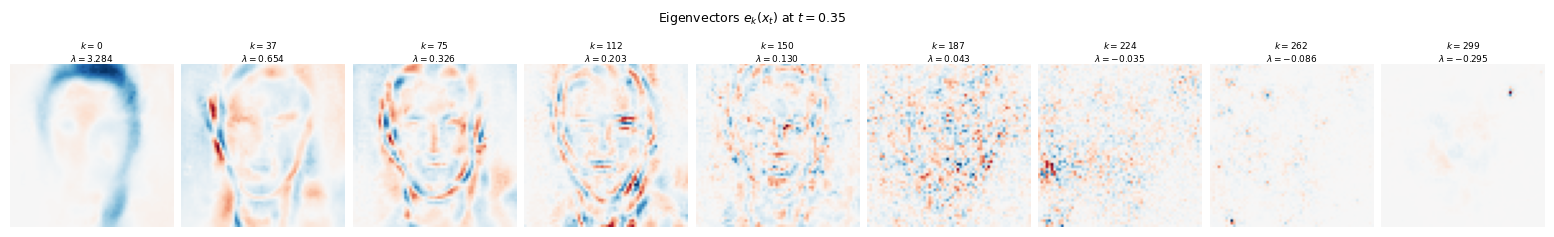

In [17]:
# leading eigenvectors
res   = results_final[T_SPEC]
k_eig = np.round(np.linspace(0, K_LANCZOS - 1, K_EIG_SHOW)).astype(int)

fig, axes_C = plt.subplots(1, K_EIG_SHOW, figsize=(2.2*K_EIG_SHOW, 2.5),
                            gridspec_kw={'wspace': 0.05})
for c_idx, k in enumerate(k_eig):
    lum  = eigvec_lum(res['E'], k, CH_OURS, IMG_OURS)
    vmax = np.abs(lum).max() + 1e-8
    axes_C[c_idx].imshow(lum, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    axes_C[c_idx].set_title(f'$k={k}$\n$λ={res["lam"][k]:.3f}$', fontsize=6.5, pad=2)
    axes_C[c_idx].axis('off')

plt.suptitle(rf'Eigenvectors $e_k(x_t)$ at $t={T_SPEC}$', fontsize=9, y=1.04)
plt.tight_layout(); plt.show()